In [70]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'

cell_classifications = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:

from scipy.ndimage import gaussian_filter
from sklearn.metrics import accuracy_score, precision_score, recall_score
import warnings

# ── Cache directory ───────────────────────────────────────────────────────
CACHE_DIR = '/Users/harryclark/Documents/spatial-manifolds/data/ta_xgboost_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

_CLF_COLS = ['mouse', 'day', 'gc_cluster_id', 'gc_shank', 'sc_x', 'sc_x_bin',
             'cov_shank', 'shank_dist', 'pR2', 'accuracy', 'precision', 'recall',
             'n_trials', 'n_ngs_cells', 'pR2_ta', 'pR2_nta',
             'accuracy_ta', 'precision_ta', 'recall_ta',
             'accuracy_nta', 'precision_nta', 'recall_nta',
             'pR2_pos', 'pR2_pos_ta', 'pR2_pos_nta']

def cache_path(mouse_id, day_id):
    return os.path.join(CACHE_DIR, f'M{mouse_id}_D{day_id:02d}_clf.pkl')


def _fmt_pR2(val):
    if val is not None and not (val is np.nan or (isinstance(val, float) and np.isnan(val))):
        return f"{val:.3f}"
    return "NaN"

def _epoch_metrics(y_true, y_pred, epoch_label):
    """Compute accuracy/precision/recall for trials belonging to one epoch label (0 or 1)."""
    mask = (y_true == epoch_label)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    yt = y_true[mask]
    yp = y_pred[mask]
    acc  = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    return acc, prec, rec

# ── Helper: derive per-trial TA labels from a linearised tuning curve ────
# tc       : 1-D or 2-D array (2-D is ravelled automatically)
# n_trials : expected output length; NaN array of this length returned on failure
def ta_labels_from_tc(tc, n_trials, peak_indices=[12, 28, 44, 60, 76], sigma=2.5):
    _nan = np.full(n_trials, np.nan)
    try:
        tc = np.nan_to_num(np.asarray(tc).ravel())
        tcs_for_spec = {0: tc, 1000: tc}
        results      = spectral_analysis(tcs_for_spec, tl, bs=bs)
        spectrograms = results[3]
        S            = spectrograms.mean(0)
        max_peaks    = np.argmax(S, axis=0)
        labels       = np.isin(max_peaks, peak_indices).astype(int)
        print(f"    [ta_labels_from_tc] labels: shape={labels.shape}, unique={np.unique(labels)}, n_peaks={labels.sum()}, n_trials={n_trials}")
        tc_smooth    = gaussian_filter(tc.astype(np.float64), sigma=sigma)
        per_trial    = get_kmeans_spatial_labels(tc_smooth, labels, bs=bs, tl=tl)
        if per_trial is None:
            print(f"    [ta_labels_from_tc] per_trial=None → returning NaN array")
            return _nan
        per_trial = np.asarray(per_trial, dtype=float)
        print(f"    [ta_labels_from_tc] per_trial: shape={per_trial.shape}, unique={np.unique(per_trial[~np.isnan(per_trial)])}")
        return per_trial
    except Exception as e:
        print(f"    [ta_labels_from_tc] {e}")
        return _nan


# ── Helper: reconstruct trial×position rate map from time-series ─────────
def reconstruct_tc(y_time, trial_number_in_time, pos_in_time, n_bins):
    trials    = np.unique(trial_number_in_time.astype(int))
    tc_hat    = np.full((len(trials), n_bins), np.nan)
    bin_edges = np.linspace(0, tl, n_bins + 1)
    for t_i, trial in enumerate(trials):
        mask  = trial_number_in_time.astype(int) == trial
        pos_t = pos_in_time[mask]
        y_t   = y_time[mask]
        for b in range(n_bins):
            b_mask = (pos_t >= bin_edges[b]) & (pos_t < bin_edges[b + 1])
            if np.sum(b_mask) > 0:
                tc_hat[t_i, b] = y_t[b_mask].mean()
    return np.nan_to_num(tc_hat)


In [72]:

# ── Patch stale caches: add pos-only pR2 columns without refitting NGS models ──
import glob

stale_files = [
    f for f in glob.glob(os.path.join(CACHE_DIR, '*.pkl'))
    if not all(c in pd.read_pickle(f).columns for c in ['pR2_pos', 'pR2_pos_ta', 'pR2_pos_nta'])
]
print(f"Found {len(stale_files)} stale cache file(s) to patch")

for cp in stale_files:
    fname = os.path.basename(cp)
    # Parse mouse_id and day_id from filename: M{mouse}_D{day:02d}_clf.pkl
    parts   = fname.replace('_clf.pkl', '').split('_')
    mouse_id = int(parts[0][1:])
    day_id   = int(parts[1][1:])
    print(f"\nPatching M{mouse_id} D{day_id:02d} ...")

    cached = pd.read_pickle(cp)

    # ── Load session data ─────────────────────────────────────────────────
    try:
        tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
            mouse_id, day_id,
            apply_zscore=False, apply_guassian_filter=False,
            source_path=source_path,
        )
    except Exception as e:
        print(f"  [skip] compute_vr_tcs failed: {e}"); continue

    last_ephys_time_bin = clusters[clusters.index[0]].count(
        bin_size=time_bs, time_units='ms').index[-1]
    ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units='s')
    dt_in_time = np.array(
        beh['travel'].bin_average(bin_size=time_bs, time_units='ms', ep=ep)
        - ((beh['trial_number'][0] - 1) * tl)
    )
    if np.any(np.isnan(dt_in_time)):
        dt_in_time = np.array(pd.Series(dt_in_time).ffill().bfill())
    pos_in_time   = dt_in_time % tl
    trial_in_time = (dt_in_time // tl) + beh['trial_number'][0]
    n_bins_sess   = int(tl / bs)
    n_trials_sess = int(last_ephys_bin // n_bins_sess)
    first_trial   = int(beh['trial_number'][0])

    # ── Fit pos-only model for each unique GC in this cached file ────────
    gc_pos_results = {}
    for gc_cid in cached['gc_cluster_id'].unique():
        gc_cid = int(gc_cid)
        if gc_cid not in tcs_time:
            continue
        y_time = np.array(tcs_time[gc_cid])

        # Derive TA labels from the original tuning curve
        if gc_cid not in tcs:
            continue
        actual_labels = ta_labels_from_tc(tcs[gc_cid], n_trials_sess)
        if np.all(np.isnan(actual_labels)):
            continue

        try:
            T_pos      = len(y_time)
            X_pos_only = pos_in_time[:T_pos].reshape(-1, 1)
            tri_t_pos  = trial_in_time[:T_pos]
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                Y_hat_pos, pR2_cv_pos = xgb_history.fit_cv(
                    X_pos_only, y_time, verbose=0, continuous_folds=True)

            t0idx_pos       = tri_t_pos.astype(int) - first_trial
            in_range_pos    = (t0idx_pos >= 0) & (t0idx_pos < len(actual_labels))
            time_labels_pos = np.full(T_pos, np.nan)
            time_labels_pos[in_range_pos] = actual_labels[t0idx_pos[in_range_pos]]
            ta_mask_pos  = (time_labels_pos == 1)
            nta_mask_pos = (time_labels_pos == 0)
            ynull_pos     = float(np.mean(y_time))
            ynull_pos_ta  = float(np.mean(y_time[ta_mask_pos]))  if ta_mask_pos.sum()  > 0 else ynull_pos
            ynull_pos_nta = float(np.mean(y_time[nta_mask_pos])) if nta_mask_pos.sum() > 0 else ynull_pos

            gc_pos_results[gc_cid] = dict(
                pR2_pos     = float(np.nanmean(pR2_cv_pos)),
                pR2_pos_ta  = float(poisson_pseudoR2(y_time[ta_mask_pos],  Y_hat_pos[ta_mask_pos],  ynull_pos_ta))
                              if ta_mask_pos.sum()  > 10 else np.nan,
                pR2_pos_nta = float(poisson_pseudoR2(y_time[nta_mask_pos], Y_hat_pos[nta_mask_pos], ynull_pos_nta))
                              if nta_mask_pos.sum() > 10 else np.nan,
            )
            print(f"  GC {gc_cid}: pR2_pos={gc_pos_results[gc_cid]['pR2_pos']:.3f}  "
                  f"pR2_pos_ta={_fmt_pR2(gc_pos_results[gc_cid]['pR2_pos_ta'])}  "
                  f"pR2_pos_nta={_fmt_pR2(gc_pos_results[gc_cid]['pR2_pos_nta'])}")
        except Exception as e:
            print(f"  [warn] GC {gc_cid} pos-only failed: {e}")

    # ── Merge new columns into cached dataframe and resave ────────────────
    pos_df = pd.DataFrame.from_dict(gc_pos_results, orient='index',
                                     columns=['pR2_pos', 'pR2_pos_ta', 'pR2_pos_nta'])
    pos_df.index.name = 'gc_cluster_id'
    pos_df = pos_df.reset_index()

    cached = cached.merge(pos_df, on='gc_cluster_id', how='left')

    # Ensure new columns exist even if no GC matched
    for col in ['pR2_pos', 'pR2_pos_ta', 'pR2_pos_nta']:
        if col not in cached.columns:
            cached[col] = np.nan

    cached.to_pickle(cp)
    print(f"  Resaved {len(cached)} rows with pos-only pR2 → {cp}")

print("\nPatching complete.")


Found 0 stale cache file(s) to patch

Patching complete.


In [73]:

# ── Session / binning parameters ─────────────────────────────────────────
nfilters       = 5
history_length = 1000   # ms
n_bins         = int(tl / bs)   # position bins per trial (100 for tl=200, bs=2)

shanks      = [0, 1, 2, 3]
# Bins: '2800–3000', '3000–3200', …, '3800–4000'
sc_x_edges  = np.arange(2800, 4001, 200)
sc_x_labels = [f'{int(sc_x_edges[i])}–{int(sc_x_edges[i+1])}' for i in range(len(sc_x_edges) - 1)]

xgb_history = MLencoding(tunemodel='xgboost',
                         cov_history=True, spike_history=False,
                         window=time_bs, n_filters=nfilters,
                         max_time=history_length)

gc_sessions    = cell_classifications[cell_classifications['cell_type'] == 'GC'][['mouse', 'day']].drop_duplicates()
ngs_sessions   = cell_classifications[cell_classifications['cell_type'] == 'NG'][['mouse', 'day']].drop_duplicates()
valid_sessions = gc_sessions.merge(ngs_sessions, on=['mouse', 'day'])
expected_shanks = {0, 1, 2, 3}

_POS_COLS = ['pR2_pos', 'pR2_pos_ta', 'pR2_pos_nta']

all_session_dfs = []

for _, sess_row in valid_sessions.iterrows():
    mouse_id = int(sess_row['mouse'])
    day_id   = int(sess_row['day'])
    cp = cache_path(mouse_id, day_id)

    # ── Load from cache if available and schema is current ───────────────
    if os.path.exists(cp):
        cached = pd.read_pickle(cp)
        if all(c in cached.columns for c in _POS_COLS):
            print(f"[cache] M{mouse_id} D{day_id:02d}  ({len(cached)} rows)")
            all_session_dfs.append(cached)
            continue
        print(f"[cache-stale] M{mouse_id} D{day_id:02d}: missing pos-only columns, recomputing")

    print(f"\n=== M{mouse_id} D{day_id:02d} ===")

    # ── Check NGS shank coverage before loading heavy data ────────────────
    sess_gcs = cell_classifications[
        (cell_classifications['mouse'] == mouse_id) &
        (cell_classifications['day']   == day_id) &
        (cell_classifications['cell_type'] == 'GC')
    ].copy()
    sess_ngs = cell_classifications[
        (cell_classifications['mouse'] == mouse_id) &
        (cell_classifications['day']   == day_id) &
        (cell_classifications['cell_type'] == 'NG')
    ].copy()

    sess_gcs['cluster_id'] = sess_gcs['cluster_id'].astype(int)
    sess_ngs['cluster_id'] = sess_ngs['cluster_id'].astype(int)
    sess_gcs = reconstruct_shank_id(sess_gcs, mouse_id, colname='probe_x')
    sess_ngs = reconstruct_shank_id(sess_ngs, mouse_id, colname='probe_x')

    ngs_shanks = set(sess_ngs['shank_id'].dropna().astype(int).unique())
    if ngs_shanks != expected_shanks:
        print(f"  NGS not on all shanks ({sorted(ngs_shanks)}) — skipping."); continue

    print(f"  GCs: {len(sess_gcs)}  NGS: {len(sess_ngs)}")

    # ── Load session data only after shank check passes ───────────────────
    try:
        tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
            mouse_id, day_id,
            apply_zscore=False, apply_guassian_filter=False,
            source_path=source_path,
        )
    except Exception as e:
        print(f"[compute_vr_tcs] failed: {e}"); continue

    # ── Time-binned position / trial mapping ─────────────────────────────
    last_ephys_time_bin = clusters[clusters.index[0]].count(
        bin_size=time_bs, time_units='ms').index[-1]
    ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units='s')
    dt_in_time = np.array(
        beh['travel'].bin_average(bin_size=time_bs, time_units='ms', ep=ep)
        - ((beh['trial_number'][0] - 1) * tl)
    )
    if np.any(np.isnan(dt_in_time)):
        dt_in_time = np.array(pd.Series(dt_in_time).ffill().bfill())
    pos_in_time   = dt_in_time % tl
    trial_in_time = (dt_in_time // tl) + beh['trial_number'][0]

    # Number of complete trials in this session
    n_trials_sess = int(last_ephys_bin // n_bins)

    # First trial number (for aligning trial_in_time → actual_labels index)
    first_trial = int(beh['trial_number'][0])

    # ── Pre-build per-shank NGS feature matrices ─────────────────────────
    ngs_X = {}
    for s in shanks:
        cids = sess_ngs[sess_ngs['shank_id'] == s]['cluster_id'].values.astype(int)
        cols = [np.array(tcs_time[c]) for c in cids if c in tcs_time]
        ngs_X[s] = np.column_stack(cols) if cols else None

    # ── Loop over GCs ─────────────────────────────────────────────────────
    sess_rows = []
    for _, gc_row in sess_gcs.iterrows():
        gc_cid   = int(gc_row['cluster_id'])
        gc_shank = int(gc_row['shank_id'])
        # SC_x is positive; take abs() to be safe
        sc_x_raw = abs(pd.to_numeric(gc_row.get('SC_x', np.nan), errors='coerce'))
        sc_x_bin = np.nan
        if not np.isnan(sc_x_raw):
            idx = int(np.digitize(sc_x_raw, sc_x_edges)) - 1
            if 0 <= idx <= len(sc_x_labels) - 1:
                sc_x_bin = sc_x_labels[idx]

        if gc_cid not in tcs or gc_cid not in tcs_time:
            continue

        actual_labels = ta_labels_from_tc(tcs[gc_cid], n_trials_sess)
        if np.all(np.isnan(actual_labels)) or len(np.unique(actual_labels[~np.isnan(actual_labels)])) < 2:
            continue
        if len(actual_labels) != n_trials_sess:
            print(f"  [warn] GC {gc_cid}: actual_labels length {len(actual_labels)} != n_trials_sess {n_trials_sess}")
            continue

        y_time = np.array(tcs_time[gc_cid])

        # ── Position-only model (fitted once per GC, broadcast to all shanks) ──
        try:
            T_pos        = len(y_time)
            X_pos_only   = pos_in_time[:T_pos].reshape(-1, 1)
            tri_t_pos    = trial_in_time[:T_pos]
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                Y_hat_pos, pR2_cv_pos = xgb_history.fit_cv(
                    X_pos_only, y_time, verbose=0, continuous_folds=True)
            # TA/NTA labels for the pos-only time window
            t0idx_pos       = tri_t_pos.astype(int) - first_trial
            in_range_pos    = (t0idx_pos >= 0) & (t0idx_pos < len(actual_labels))
            time_labels_pos = np.full(T_pos, np.nan)
            time_labels_pos[in_range_pos] = actual_labels[t0idx_pos[in_range_pos]]
            ta_mask_pos   = (time_labels_pos == 1)
            nta_mask_pos  = (time_labels_pos == 0)
            ynull_pos     = float(np.mean(y_time))
            ynull_pos_ta  = float(np.mean(y_time[ta_mask_pos]))  if ta_mask_pos.sum()  > 0 else ynull_pos
            ynull_pos_nta = float(np.mean(y_time[nta_mask_pos])) if nta_mask_pos.sum() > 0 else ynull_pos
            pR2_pos_all = float(np.nanmean(pR2_cv_pos))
            pR2_pos_ta  = float(poisson_pseudoR2(y_time[ta_mask_pos],  Y_hat_pos[ta_mask_pos],  ynull_pos_ta)) \
                          if ta_mask_pos.sum()  > 10 else np.nan
            pR2_pos_nta = float(poisson_pseudoR2(y_time[nta_mask_pos], Y_hat_pos[nta_mask_pos], ynull_pos_nta)) \
                          if nta_mask_pos.sum() > 10 else np.nan
            print(f"  [pos-only] GC {gc_cid}: pR2={_fmt_pR2(pR2_pos_all)}  "
                  f"pR2_ta={_fmt_pR2(pR2_pos_ta)}  pR2_nta={_fmt_pR2(pR2_pos_nta)}")
        except Exception as e:
            print(f"  [pos-only] GC {gc_cid}: {e}")
            pR2_pos_all = pR2_pos_ta = pR2_pos_nta = np.nan

        for cov_shank in shanks:
            X = ngs_X.get(cov_shank)
            if X is None:
                continue
            T     = min(len(y_time), X.shape[0])
            X_use = X[:T]
            y_use = y_time[:T]
            pos_t = pos_in_time[:T]
            tri_t = trial_in_time[:T]

            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    Y_hat, pR2_cv = xgb_history.fit_cv(
                        X_use, y_use, verbose=0, continuous_folds=True)

                # ── pR2 split by TA / non-TA epochs ──────────────────────
                # Map each time bin → 0-indexed trial → actual_label
                t0idx       = tri_t.astype(int) - first_trial
                in_range    = (t0idx >= 0) & (t0idx < len(actual_labels))
                time_labels = np.full(len(tri_t), np.nan)
                time_labels[in_range] = actual_labels[t0idx[in_range]]

                ta_mask  = (time_labels == 1)
                nta_mask = (time_labels == 0)
                ynull     = float(np.mean(y_use))
                ynull_ta  = float(np.mean(y_use[ta_mask])) if ta_mask.sum() > 0 else ynull
                ynull_nta = float(np.mean(y_use[nta_mask])) if nta_mask.sum() > 0 else ynull

                pR2_ta   = float(poisson_pseudoR2(y_use[ta_mask],  Y_hat[ta_mask],  ynull_ta)) \
                           if ta_mask.sum() > 10 else np.nan
                pR2_nta  = float(poisson_pseudoR2(y_use[nta_mask], Y_hat[nta_mask], ynull_nta)) \
                           if nta_mask.sum() > 10 else np.nan
                pR2_all  = float(np.nanmean(pR2_cv))

                print(f"    GC {gc_cid} cov_shank {cov_shank}: "
                      f"pR2_all={_fmt_pR2(pR2_all)}  "
                      f"pR2_ta={_fmt_pR2(pR2_ta)}  "
                      f"pR2_nta={_fmt_pR2(pR2_nta)}  "
                      f"(n_ta={ta_mask.sum()}, n_nta={nta_mask.sum()})")

                tc_hat        = reconstruct_tc(Y_hat, tri_t, pos_t, n_bins)
                n_pred_trials = tc_hat.shape[0]
                pred_labels   = ta_labels_from_tc(tc_hat, n_pred_trials)
                if np.all(np.isnan(pred_labels)):
                    continue
                if len(pred_labels) != n_pred_trials:
                    print(f"    [warn] GC {gc_cid} cov_shank {cov_shank}: pred_labels length {len(pred_labels)} != n_pred_trials {n_pred_trials}")
                    continue

                # Use only trials where both labels are valid
                valid = ~np.isnan(actual_labels[:n_pred_trials]) & ~np.isnan(pred_labels)
                n = valid.sum()
                if n == 0:
                    continue
                y_true = actual_labels[:n_pred_trials][valid].astype(int)
                y_pred = pred_labels[valid].astype(int)
                if len(np.unique(y_true)) < 2:
                    continue

                # ── Per-epoch accuracy / precision / recall ───────────────
                # TA trials (y_true==1): how well are TA trials classified?
                # NTA trials (y_true==0): how well are NTA trials classified?
                acc_ta,  prec_ta,  rec_ta  = _epoch_metrics(y_true, y_pred, epoch_label=1)
                acc_nta, prec_nta, rec_nta = _epoch_metrics(y_true, y_pred, epoch_label=0)

                prec_val = precision_score(y_true, y_pred, zero_division=0)
                rec_val  = recall_score(y_true, y_pred, zero_division=0)

                sess_rows.append(dict(
                    mouse=mouse_id, day=day_id,
                    gc_cluster_id=gc_cid,
                    gc_shank=gc_shank,
                    sc_x=sc_x_raw,
                    sc_x_bin=sc_x_bin,
                    cov_shank=cov_shank,
                    shank_dist=abs(gc_shank - cov_shank),
                    pR2=pR2_all,
                    accuracy=accuracy_score(y_true, y_pred),
                    precision=prec_val,
                    recall=rec_val,
                    n_trials=int(n),
                    n_ngs_cells=X_use.shape[1],
                    pR2_ta=pR2_ta,
                    pR2_nta=pR2_nta,
                    accuracy_ta=acc_ta,   precision_ta=prec_ta,   recall_ta=rec_ta,
                    accuracy_nta=acc_nta, precision_nta=prec_nta, recall_nta=rec_nta,
                    pR2_pos=pR2_pos_all,
                    pR2_pos_ta=pR2_pos_ta,
                    pR2_pos_nta=pR2_pos_nta,
                ))
            except Exception as e:
                print(f"    [skip] GC {gc_cid} cov_shank {cov_shank}: {e}")

    sess_df = pd.DataFrame(sess_rows, columns=_CLF_COLS) if sess_rows else pd.DataFrame(columns=_CLF_COLS)
    if len(sess_df) > 0:
        sess_df.to_pickle(cp)
        print(f"  Cached {len(sess_df)} rows → {cp}")
        all_session_dfs.append(sess_df)
    else:
        print(f"  No results for M{mouse_id} D{day_id:02d} (cache not written)")

clf_df = (pd.concat(all_session_dfs, ignore_index=True)
          if all_session_dfs else pd.DataFrame(columns=_CLF_COLS))

# ── Post-load fix: ensure sc_x is positive and sc_x_bin is a string label ──
if len(clf_df) > 0:
    clf_df['sc_x'] = pd.to_numeric(clf_df['sc_x'], errors='coerce').abs()
    def _assign_sc_x_bin(sc_x_val):
        if pd.isna(sc_x_val):
            return np.nan
        idx = int(np.digitize(sc_x_val, sc_x_edges)) - 1
        if 0 <= idx <= len(sc_x_labels) - 1:
            return sc_x_labels[idx]
        return np.nan
    clf_df['sc_x_bin'] = clf_df['sc_x'].apply(_assign_sc_x_bin)
    n_fixed = clf_df['sc_x_bin'].notna().sum()
    print(f"  sc_x_bin assigned for {n_fixed}/{len(clf_df)} rows  "
          f"(bins present: {sorted(clf_df['sc_x_bin'].dropna().unique())})")

# ── Derive F1 from precision and recall ──────────────────────────────────
denom = (clf_df['precision'] + clf_df['recall']).replace(0, np.nan)
clf_df['f1'] = 2 * clf_df['precision'] * clf_df['recall'] / denom

n_sess = clf_df[['mouse', 'day']].drop_duplicates().shape[0] if len(clf_df) > 0 else 0
print(f"\nDone. {len(clf_df)} rows  ({n_sess} sessions)")
clf_df.head()


[cache] M20 D14  (16 rows)
[cache] M20 D15  (12 rows)
[cache] M20 D16  (44 rows)

=== M20 D17 ===
  NGS not on all shanks ([np.int64(1), np.int64(2), np.int64(3)]) — skipping.
[cache] M20 D18  (16 rows)
[cache] M20 D19  (4 rows)

=== M20 D20 ===
  NGS not on all shanks ([np.int64(1)]) — skipping.

=== M20 D21 ===
  NGS not on all shanks ([np.int64(2)]) — skipping.

=== M20 D23 ===
  NGS not on all shanks ([np.int64(1)]) — skipping.

=== M20 D24 ===
  NGS not on all shanks ([np.int64(2)]) — skipping.

=== M20 D25 ===
  NGS not on all shanks ([np.int64(0)]) — skipping.

=== M20 D26 ===
  NGS not on all shanks ([np.int64(3)]) — skipping.

=== M21 D15 ===
M21 unique probe_x values (before remap): [np.float64(250.0), np.float64(282.0), np.float64(500.0), np.float64(750.0), np.float64(782.0)]
M21 unique probe_x values (after remap):  [np.float64(0.0), np.float64(32.0), np.float64(282.0), np.float64(500.0), np.float64(532.0)]
M21 unique probe_x values (before remap): [np.float64(250.0), np.fl

,mouse,day,gc_cluster_id,gc_shank,sc_x,sc_x_bin,cov_shank,shank_dist,pR2,accuracy,...,accuracy_ta,precision_ta,recall_ta,accuracy_nta,precision_nta,recall_nta,pR2_pos,pR2_pos_ta,pR2_pos_nta,f1
0,20,14,34,0,3150.0,3000–3200,0,0,-0.011465,0.651786,...,0.263158,1.0,0.263158,0.851351,0.0,0.0,0.027396,0.007876,-0.003294,0.338983
1,20,14,34,0,3150.0,3000–3200,1,1,0.046603,0.464286,...,0.289474,1.0,0.289474,0.554054,0.0,0.0,0.027396,0.007876,-0.003294,0.268293
2,20,14,34,0,3150.0,3000–3200,2,2,0.051765,0.383929,...,1.000000,1.0,1.000000,0.067568,0.0,0.0,0.027396,0.007876,-0.003294,0.524138
3,20,14,34,0,3150.0,3000–3200,3,3,-0.003173,0.598214,...,0.157895,1.0,0.157895,0.824324,0.0,0.0,0.027396,0.007876,-0.003294,0.210526
4,20,14,103,1,3330.0,3200–3400,0,1,-0.000081,0.428571,...,0.090909,1.0,0.090909,0.913043,0.0,0.0,0.016471,0.025529,0.007102,0.157895


In [74]:

# ── Save ──────────────────────────────────────────────────────────────────
save_path = '/Users/harryclark/Documents/spatial-manifolds/data/ta_xgboost_shank_clf.csv'
clf_df.to_csv(save_path, index=False)
print(f"Saved {len(clf_df)} rows → {save_path}")


Saved 872 rows → /Users/harryclark/Documents/spatial-manifolds/data/ta_xgboost_shank_clf.csv


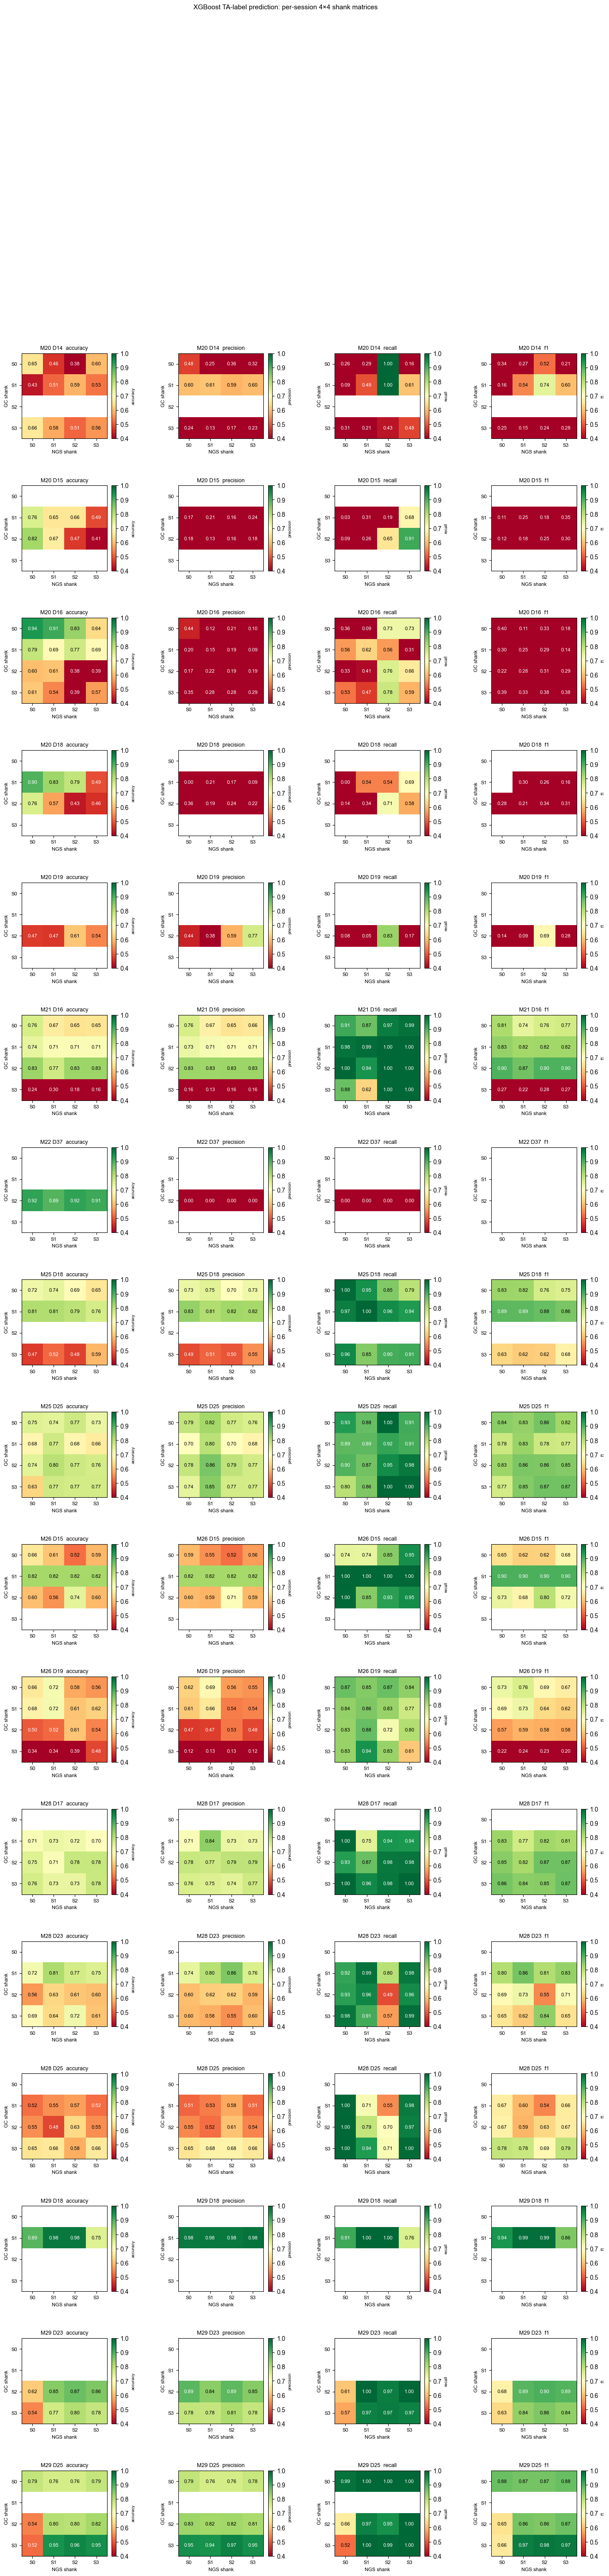

Saved ta_xgboost_shank_matrices.pdf


In [75]:

# ── Per-session 4×4 matrices  (rows=GC shank, cols=NGS shank) ───────────
import matplotlib.pyplot as plt
import numpy as np

if 'f1' not in clf_df.columns:
    _denom = (clf_df['precision'] + clf_df['recall']).replace(0, np.nan)
    clf_df['f1'] = 2 * clf_df['precision'] * clf_df['recall'] / _denom

valid_sess_list = (
    clf_df[['mouse','day']].drop_duplicates().sort_values(['mouse','day']).values
)
n_sess  = len(valid_sess_list)
shanks  = [0, 1, 2, 3]
metrics = ['accuracy', 'precision', 'recall', 'f1']
cmap    = 'RdYlGn'
vmin, vmax = 0.4, 1.0

fig, axes = plt.subplots(n_sess, 4, figsize=(17, 3.8 * n_sess),
                         gridspec_kw={'wspace': 0.38, 'hspace': 0.55})
if n_sess == 1:
    axes = axes[np.newaxis, :]

tick_labels = [f'S{s}' for s in shanks]

for row_i, (mouse_id, day_id) in enumerate(valid_sess_list):
    sess = clf_df[(clf_df['mouse'] == mouse_id) & (clf_df['day'] == day_id)]

    for col_i, metric in enumerate(metrics):
        mat = np.full((4, 4), np.nan)
        for i, gc_s in enumerate(shanks):
            for j, cov_s in enumerate(shanks):
                vals = sess[(sess['gc_shank'] == gc_s) &
                            (sess['cov_shank'] == cov_s)][metric].dropna()
                if len(vals):
                    mat[i, j] = vals.mean()

        ax = axes[row_i, col_i]
        im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax,
                       aspect='equal', interpolation='nearest')
        for i in range(4):
            for j in range(4):
                if not np.isnan(mat[i, j]):
                    txt_color = 'k' if 0.52 < mat[i, j] < 0.88 else 'w'
                    ax.text(j, i, f'{mat[i,j]:.2f}',
                            ha='center', va='center', fontsize=8, color=txt_color)
        ax.set_xticks(range(4)); ax.set_xticklabels(tick_labels, fontsize=8)
        ax.set_yticks(range(4)); ax.set_yticklabels(tick_labels, fontsize=8)
        ax.set_xlabel('NGS shank', fontsize=8)
        ax.set_ylabel('GC shank', fontsize=8)
        ax.set_title(f'M{int(mouse_id)} D{int(day_id)}  {metric}', fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label(metric, fontsize=7)

plt.suptitle('XGBoost TA-label prediction: per-session 4×4 shank matrices',
             fontsize=11, y=1.002)
os.makedirs(fig_path, exist_ok=True)
plt.savefig(fig_path + 'ta_xgboost_shank_matrices.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ta_xgboost_shank_matrices.pdf")


Mean TA prevalence = 0.597  →  chance: acc=0.500  prec=0.597  rec=0.500  f1=0.544


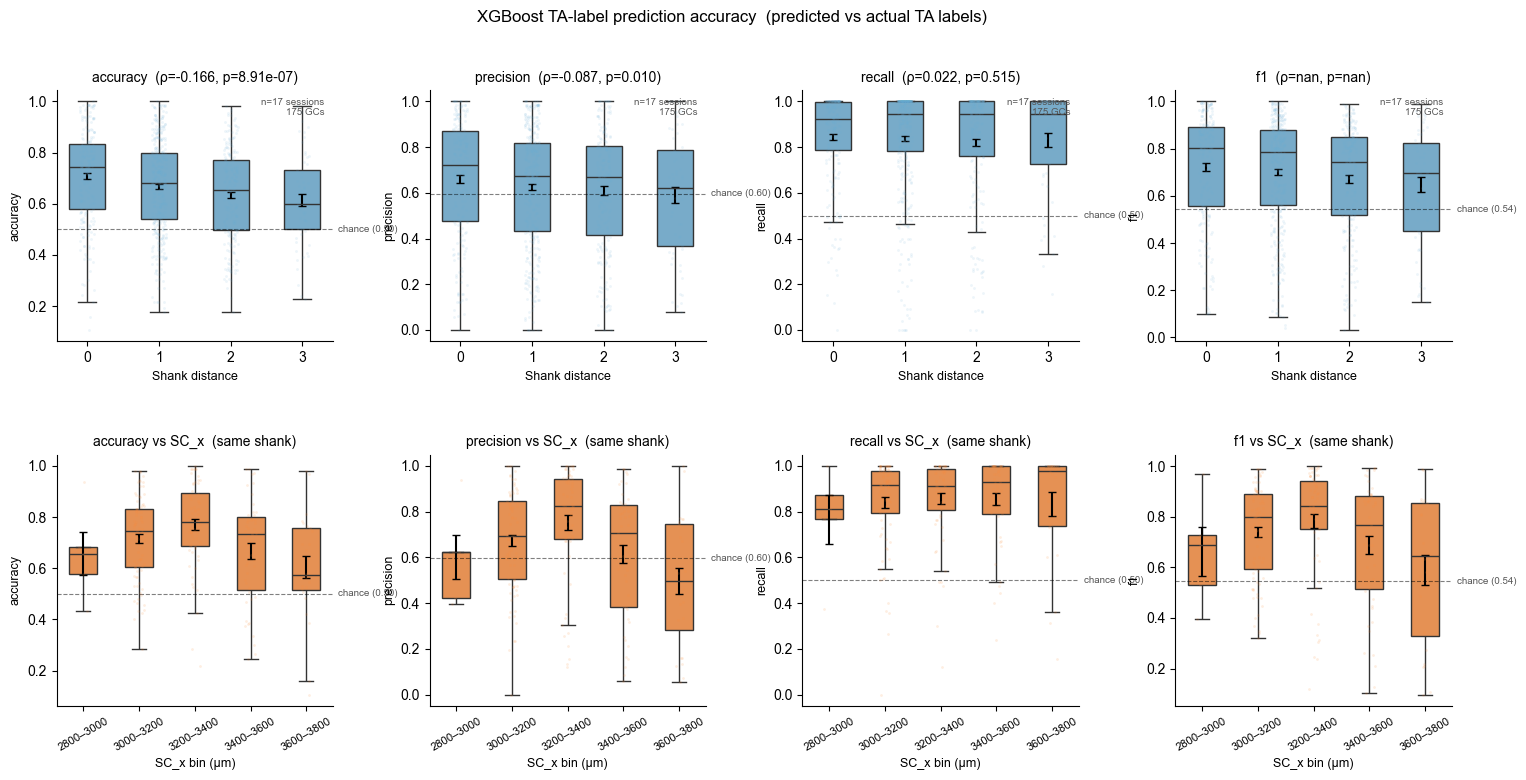

Saved ta_xgboost_clf_summary.pdf


In [76]:

# ── Population summary: accuracy / precision / recall / f1 vs shank dist and SC_x bin ──
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

if 'f1' not in clf_df.columns:
    _denom = (clf_df['precision'] + clf_df['recall']).replace(0, np.nan)
    clf_df['f1'] = 2 * clf_df['precision'] * clf_df['recall'] / _denom

# ── Empirical chance levels ───────────────────────────────────────────────
# Recover mean TA prevalence (p) from stored accuracy/precision/recall:
#   p = (1 - accuracy) * precision  /  (precision*(1 - 2*recall) + recall)
# Then for a random classifier (predicts 1 with probability 0.5):
#   chance accuracy  = 0.5
#   chance precision = p          (always equals prevalence regardless of threshold)
#   chance recall    = 0.5
#   chance F1        = p / (p + 0.5)
_pta_denom = clf_df['precision'] * (1 - 2 * clf_df['recall']) + clf_df['recall']
_p_ta      = ((1 - clf_df['accuracy']) * clf_df['precision']
              / _pta_denom.replace(0, np.nan)).clip(0, 1)
mean_p_ta  = float(_p_ta.dropna().mean())
chance = {
    'accuracy':  0.5,
    'precision': mean_p_ta,
    'recall':    0.5,
    'f1':        mean_p_ta / (mean_p_ta + 0.5),
}
print(f"Mean TA prevalence = {mean_p_ta:.3f}  →  "
      f"chance: acc={chance['accuracy']:.3f}  "
      f"prec={chance['precision']:.3f}  "
      f"rec={chance['recall']:.3f}  "
      f"f1={chance['f1']:.3f}")

metrics     = ['accuracy', 'precision', 'recall', 'f1']
dist_order  = sorted(clf_df['shank_dist'].unique())
sc_x_order  = [b for b in sc_x_labels if b in clf_df['sc_x_bin'].unique()]

fig, axes = plt.subplots(2, 4, figsize=(18, 8),
                         gridspec_kw={'hspace': 0.45, 'wspace': 0.35})

# ── Top row: metric vs shank distance ────────────────────────────────────
for col, metric in enumerate(metrics):
    ax = axes[0, col]
    sns.boxplot(data=clf_df, x='shank_dist', y=metric,
                order=dist_order, color='#6baed6',
                width=0.5, fliersize=0, linecolor='#333333', ax=ax)
    sns.stripplot(data=clf_df, x='shank_dist', y=metric,
                  order=dist_order, color='#6baed6',
                  alpha=0.12, jitter=True, size=2, ax=ax)
    for i, d in enumerate(dist_order):
        v = clf_df.loc[clf_df['shank_dist'] == d, metric].dropna()
        if len(v):
            ax.errorbar(i, v.mean(), yerr=v.sem(),
                        fmt='none', color='k', capsize=3, linewidth=1.5)
    r, p = spearmanr(clf_df['shank_dist'], clf_df[metric])
    p_str = f'{p:.2e}' if p < 0.001 else f'{p:.3f}'
    ax.set_title(f'{metric}  (ρ={r:.3f}, p={p_str})', fontsize=10)
    ax.set_xlabel('Shank distance', fontsize=9)
    ax.set_ylabel(metric, fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    n_sess = clf_df[['mouse', 'day']].drop_duplicates().shape[0]
    n_gc   = clf_df['gc_cluster_id'].nunique()
    ax.text(0.97, 0.97, f'n={n_sess} sessions\n{n_gc} GCs',
            transform=ax.transAxes, fontsize=7, ha='right', va='top', color='#555555')
    ch = chance[metric]
    ax.axhline(ch, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.annotate(f'chance ({ch:.2f})',
                xy=(1, ch), xycoords=('axes fraction', 'data'),
                xytext=(4, 0), textcoords='offset points',
                fontsize=7, color='#555555', va='center', ha='left', clip_on=False)

# ── Bottom row: metric vs SC_x bin ───────────────────────────────────────
same = clf_df[clf_df['shank_dist'] == 0]

for col, metric in enumerate(metrics):
    ax = axes[1, col]
    sc_x_present = [b for b in sc_x_order if b in same['sc_x_bin'].unique()]
    sns.boxplot(data=same, x='sc_x_bin', y=metric,
                order=sc_x_present, color='#fd8d3c',
                width=0.5, fliersize=0, linecolor='#333333', ax=ax)
    sns.stripplot(data=same, x='sc_x_bin', y=metric,
                  order=sc_x_present, color='#fd8d3c',
                  alpha=0.15, jitter=True, size=2, ax=ax)
    for i, b in enumerate(sc_x_present):
        v = same.loc[same['sc_x_bin'] == b, metric].dropna()
        if len(v):
            ax.errorbar(i, v.mean(), yerr=v.sem(),
                        fmt='none', color='k', capsize=3, linewidth=1.5)
    ax.set_title(f'{metric} vs SC_x  (same shank)', fontsize=10)
    ax.set_xlabel('SC_x bin (µm)', fontsize=9)
    ax.set_ylabel(metric, fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ch = chance[metric]
    ax.axhline(ch, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.annotate(f'chance ({ch:.2f})',
                xy=(1, ch), xycoords=('axes fraction', 'data'),
                xytext=(4, 0), textcoords='offset points',
                fontsize=7, color='#555555', va='center', ha='left', clip_on=False)

fig.suptitle('XGBoost TA-label prediction accuracy  (predicted vs actual TA labels)',
             fontsize=12)
os.makedirs(fig_path, exist_ok=True)
plt.savefig(fig_path + 'ta_xgboost_clf_summary.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved ta_xgboost_clf_summary.pdf")


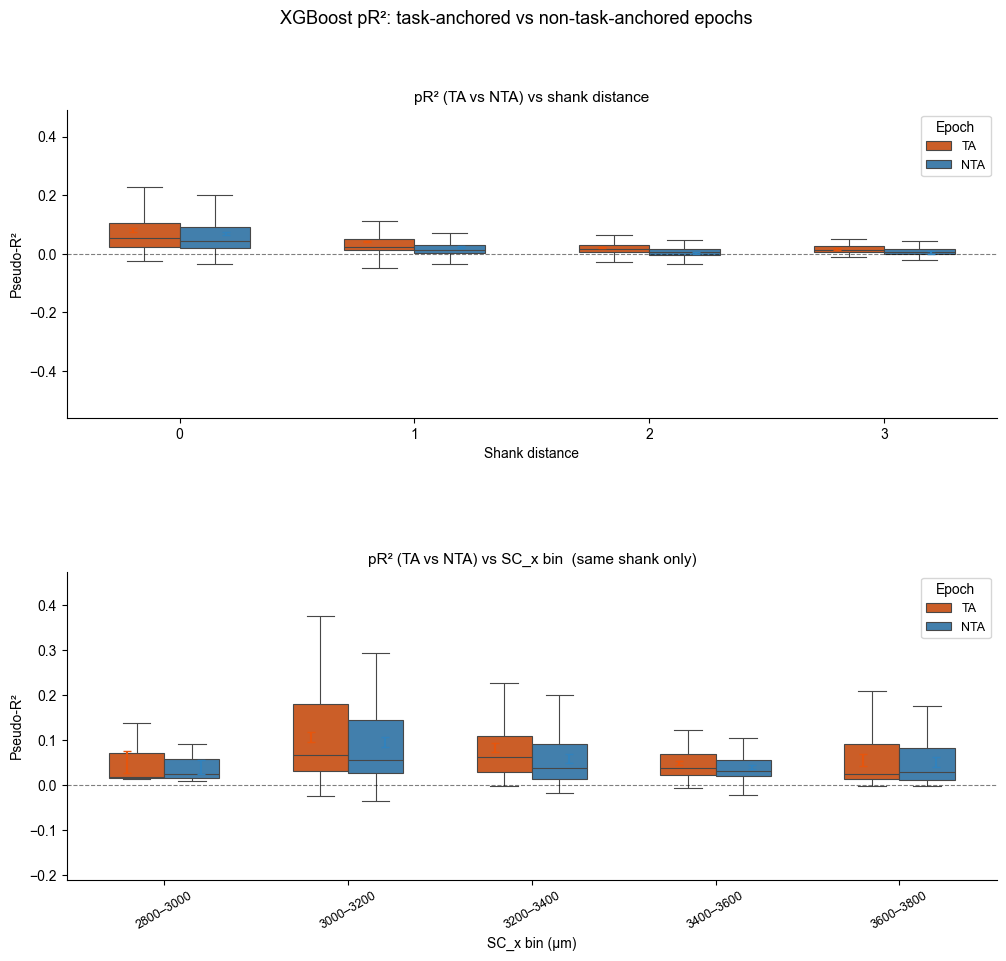

Saved ta_xgboost_pR2_ta_nta.pdf


In [77]:

# ── pR2 (TA vs NTA) vs shank distance and SC_x bin ───────────────────────
import seaborn as sns
import matplotlib.pyplot as plt

palette_epoch = {'TA': '#e6550d', 'NTA': '#3182bd'}

# Melt pR2_ta / pR2_nta into long form
# value_name must not clash with existing clf_df columns (which include 'pR2')
pr2_long = pd.melt(
    clf_df,
    id_vars=['mouse', 'day', 'gc_cluster_id', 'gc_shank', 'sc_x_bin', 'shank_dist'],
    value_vars=['pR2_ta', 'pR2_nta'],
    var_name='epoch', value_name='pR2_val',
).dropna(subset=['pR2_val'])
pr2_long['epoch'] = pr2_long['epoch'].map({'pR2_ta': 'TA', 'pR2_nta': 'NTA'})

dist_order   = sorted(clf_df['shank_dist'].unique())
sc_x_order   = [b for b in sc_x_labels if b in clf_df['sc_x_bin'].unique()]

fig, axes = plt.subplots(2, 1, figsize=(12, 10),
                         gridspec_kw={'hspace': 0.5})

# ── Top: pR2 vs shank distance ────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=pr2_long, x='shank_dist', y='pR2_val', hue='epoch',
    order=dist_order, hue_order=['TA', 'NTA'],
    palette=palette_epoch,
    width=0.6, fliersize=0, linewidth=0.8, ax=ax,
)
for ei, epoch in enumerate(['TA', 'NTA']):
    sub = pr2_long[pr2_long['epoch'] == epoch]
    offsets = [-0.2, 0.2]
    for xi, d in enumerate(dist_order):
        v = sub.loc[sub['shank_dist'] == d, 'pR2_val'].dropna()
        if len(v):
            ax.errorbar(xi + offsets[ei], v.mean(), yerr=v.sem(),
                        fmt='none', color=palette_epoch[epoch],
                        capsize=3, linewidth=1.5, zorder=5)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Shank distance', fontsize=10)
ax.set_ylabel('Pseudo-R²', fontsize=10)
ax.set_title('pR² (TA vs NTA) vs shank distance', fontsize=11)
ax.legend(title='Epoch', fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── Bottom: pR2 vs SC_x bin (same shank only) ────────────────────────────
ax = axes[1]
same_pr2 = pr2_long[pr2_long['shank_dist'] == 0]
sc_x_present = [b for b in sc_x_order if b in same_pr2['sc_x_bin'].unique()]

sns.boxplot(
    data=same_pr2, x='sc_x_bin', y='pR2_val', hue='epoch',
    order=sc_x_present, hue_order=['TA', 'NTA'],
    palette=palette_epoch,
    width=0.6, fliersize=0, linewidth=0.8, ax=ax,
)
for ei, epoch in enumerate(['TA', 'NTA']):
    sub = same_pr2[same_pr2['epoch'] == epoch]
    offsets = [-0.2, 0.2]
    for xi, b in enumerate(sc_x_present):
        v = sub.loc[sub['sc_x_bin'] == b, 'pR2_val'].dropna()
        if len(v):
            ax.errorbar(xi + offsets[ei], v.mean(), yerr=v.sem(),
                        fmt='none', color=palette_epoch[epoch],
                        capsize=3, linewidth=1.5, zorder=5)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('SC_x bin (µm)', fontsize=10)
ax.set_ylabel('Pseudo-R²', fontsize=10)
ax.set_title('pR² (TA vs NTA) vs SC_x bin  (same shank only)', fontsize=11)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.legend(title='Epoch', fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('XGBoost pR²: task-anchored vs non-task-anchored epochs', fontsize=13)
os.makedirs(fig_path, exist_ok=True)
plt.savefig(fig_path + 'ta_xgboost_pR2_ta_nta.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved ta_xgboost_pR2_ta_nta.pdf")


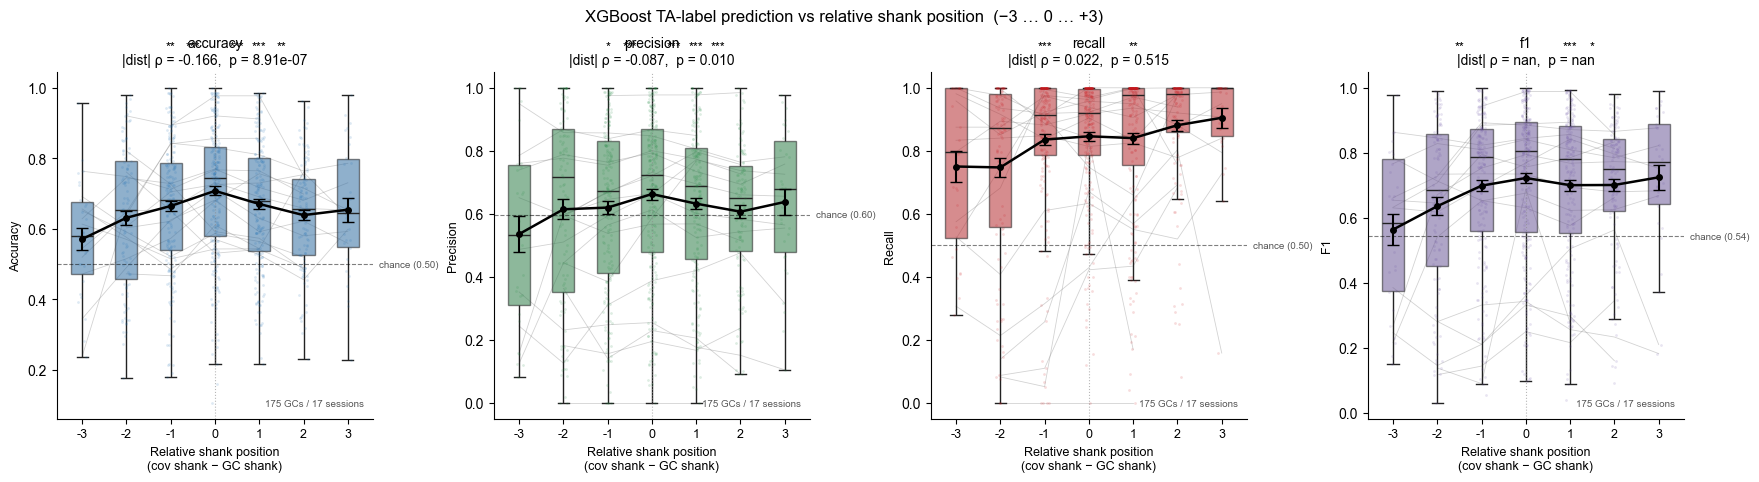

Saved ta_xgboost_shank_dist_metrics.pdf  (mean TA prevalence = 0.597)


In [78]:

# ── Shank-distance plot: accuracy / precision / recall / f1 vs relative shank position ──
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, wilcoxon

if 'f1' not in clf_df.columns:
    _denom = (clf_df['precision'] + clf_df['recall']).replace(0, np.nan)
    clf_df['f1'] = 2 * clf_df['precision'] * clf_df['recall'] / _denom

# ── Empirical chance levels (same formula as summary plot) ────────────────
_pta_denom = clf_df['precision'] * (1 - 2 * clf_df['recall']) + clf_df['recall']
_p_ta      = ((1 - clf_df['accuracy']) * clf_df['precision']
              / _pta_denom.replace(0, np.nan)).clip(0, 1)
mean_p_ta  = float(_p_ta.dropna().mean())
chance = {
    'accuracy':  0.5,
    'precision': mean_p_ta,
    'recall':    0.5,
    'f1':        mean_p_ta / (mean_p_ta + 0.5),
}

metrics      = ['accuracy', 'precision', 'recall', 'f1']
palette      = {'accuracy': '#2171b5', 'precision': '#238b45', 'recall': '#cb181d', 'f1': '#6a51a3'}

# Signed relative shank position: cov_shank − gc_shank  (−3 … 0 … +3)
plot_df = clf_df.copy()
plot_df['signed_dist'] = plot_df['cov_shank'].astype(int) - plot_df['gc_shank'].astype(int)
dist_order = list(range(-3, 4))   # −3, −2, −1, 0, 1, 2, 3
n_dist     = len(dist_order)

fig, axes = plt.subplots(1, 4, figsize=(21, 4.5),
                         gridspec_kw={'wspace': 0.38})

for ax, metric in zip(axes, metrics):
    color = palette[metric]

    # ── Boxplot + strip ───────────────────────────────────────────────────
    sns.boxplot(
        data=plot_df, x='signed_dist', y=metric,
        order=dist_order, color=color,
        width=0.5, fliersize=0, linecolor='#222222',
        boxprops=dict(alpha=0.55), ax=ax,
    )
    sns.stripplot(
        data=plot_df, x='signed_dist', y=metric,
        order=dist_order, color=color,
        alpha=0.15, jitter=True, size=2, ax=ax,
    )

    # ── Mean ± SEM overlay ────────────────────────────────────────────────
    xs     = list(range(n_dist))
    means  = [plot_df.loc[plot_df['signed_dist'] == d, metric].dropna().mean() for d in dist_order]
    sems   = [plot_df.loc[plot_df['signed_dist'] == d, metric].dropna().sem()  for d in dist_order]
    ax.plot(xs, means, color='k', lw=1.8, zorder=5, marker='o', markersize=4)
    ax.errorbar(xs, means, yerr=sems, fmt='none', color='k',
                capsize=4, linewidth=1.5, zorder=6)

    # ── Spearman rho (using absolute distance to capture the U-shape) ─────
    r, p = spearmanr(plot_df['signed_dist'].abs(), plot_df[metric].values)
    p_str = f'{p:.2e}' if p < 0.001 else f'{p:.3f}'
    ax.set_title(f'{metric}\n|dist| ρ = {r:.3f},  p = {p_str}', fontsize=10)

    # ── Wilcoxon significance vs dist = 0 (per-GC means) ─────────────────
    d0_vals = (
        plot_df[plot_df['signed_dist'] == 0]
        .groupby(['mouse', 'day', 'gc_cluster_id'])[metric].mean()
    )
    y_top    = ax.get_ylim()[1]
    bar_step = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.06
    for xi, d in enumerate(dist_order):
        if d == 0:
            continue
        d_vals = (
            plot_df[plot_df['signed_dist'] == d]
            .groupby(['mouse', 'day', 'gc_cluster_id'])[metric].mean()
        )
        common = d0_vals.index.intersection(d_vals.index)
        if len(common) < 5:
            continue
        _, pw = wilcoxon(d0_vals[common], d_vals[common])
        if pw < 0.05:
            sig   = '***' if pw < 0.001 else ('**' if pw < 0.01 else '*')
            zero_xi = dist_order.index(0)
            bar_y = y_top + bar_step * 0.8
            ax.annotate('', xy=(xi, bar_y), xytext=(zero_xi, bar_y),
                        arrowprops=dict(arrowstyle='-', color='k', lw=1))
            ax.text((xi + zero_xi) / 2, bar_y + bar_step * 0.1, sig,
                    ha='center', va='bottom', fontsize=9, color='k')

    # ── Prevalence-adjusted chance line ───────────────────────────────────
    ch = chance[metric]
    ax.axhline(ch, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.annotate(f'chance ({ch:.2f})',
                xy=(1, ch), xycoords=('axes fraction', 'data'),
                xytext=(4, 0), textcoords='offset points',
                fontsize=7, color='#555555', va='center', ha='left', clip_on=False)

    ax.axvline(dist_order.index(0), color='#888888', lw=0.8, ls=':', alpha=0.6)
    ax.set_xlabel('Relative shank position\n(cov shank − GC shank)', fontsize=9)
    ax.set_ylabel(metric.capitalize(), fontsize=9)
    ax.set_xticks(xs)
    ax.set_xticklabels([str(d) for d in dist_order], fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ── Per-session mean trend lines (thin, grey) ─────────────────────────
    for (mid, did), sg in plot_df.groupby(['mouse', 'day']):
        sess_means = [sg[sg['signed_dist'] == d][metric].mean() for d in dist_order]
        ax.plot(xs, sess_means, color='grey', lw=0.6, alpha=0.35, zorder=1)

    n_gc_v   = plot_df['gc_cluster_id'].nunique()
    n_sess_v = plot_df[['mouse', 'day']].drop_duplicates().shape[0]
    ax.text(0.97, 0.03, f'{n_gc_v} GCs / {n_sess_v} sessions',
            transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
            color='#555555')

fig.suptitle(
    'XGBoost TA-label prediction vs relative shank position  (−3 … 0 … +3)',
    fontsize=12, y=1.02,
)
os.makedirs(fig_path, exist_ok=True)
plt.savefig(fig_path + 'ta_xgboost_shank_dist_metrics.pdf',
            dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved ta_xgboost_shank_dist_metrics.pdf  (mean TA prevalence = {mean_p_ta:.3f})")


M21 unique probe_x values (before remap): [np.float64(0.0), np.float64(32.0), np.float64(250.0), np.float64(282.0), np.float64(500.0), np.float64(532.0), np.float64(750.0), np.float64(782.0)]
M21 unique probe_x values (after remap):  [np.float64(0.0), np.float64(32.0), np.float64(250.0), np.float64(282.0), np.float64(500.0), np.float64(532.0), np.float64(750.0), np.float64(782.0)]


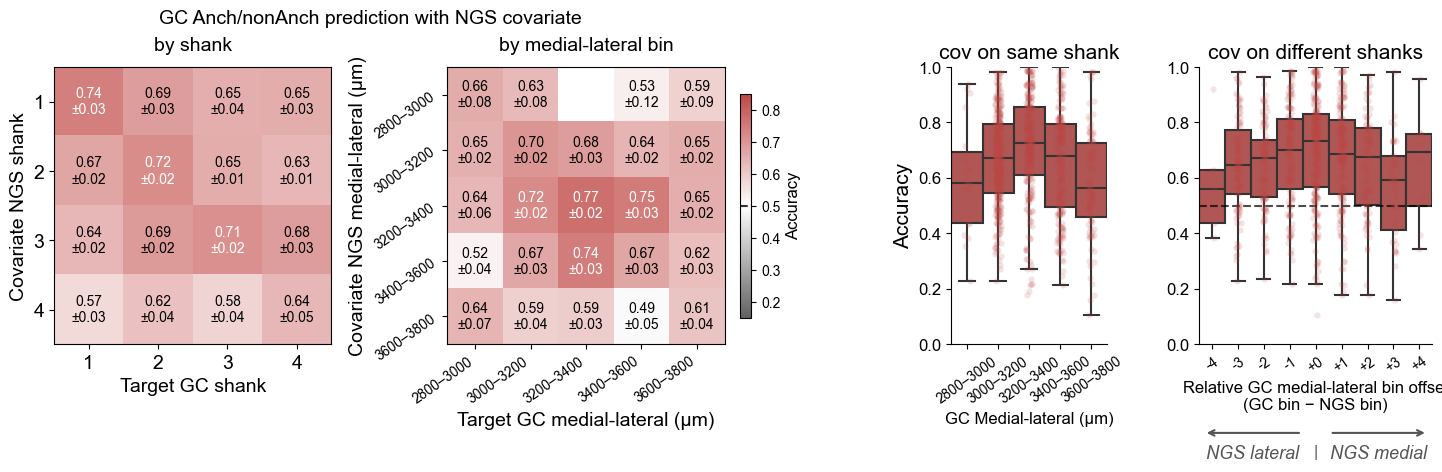

Saved ta_xgboost_sc_x_matrix.pdf  (mean TA prevalence = 0.597)
Relative-bin boxplot: 843 rows from 174 GCs


In [83]:
# ── Shank matrix + SC_x matrix (shared colorbar) + boxplots ──────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import numpy as np
import pandas as pd

gc_color_dark = gc_color

if 'f1' not in clf_df.columns:
    _denom = (clf_df['precision'] + clf_df['recall']).replace(0, np.nan)
    clf_df['f1'] = 2 * clf_df['precision'] * clf_df['recall'] / _denom

# ── Local 5-bin SC_x scheme (200 µm bins, 2800–3800) ─────────────────────
_mx_edges  = np.array([2800, 3000, 3200, 3400, 3600, 3800])
_mx_labels = [f'{int(_mx_edges[i])}–{int(_mx_edges[i+1])}' for i in range(len(_mx_edges) - 1)]

def _mx_bin(val):
    if pd.isna(val):
        return np.nan
    idx = int(np.digitize(val, _mx_edges)) - 1
    return _mx_labels[idx] if 0 <= idx < len(_mx_labels) else np.nan

ngs_cells = cell_classifications[cell_classifications['cell_type'] == 'NG'].copy()
ngs_cells['cluster_id'] = ngs_cells['cluster_id'].astype(int)

_ngs_chunks = []
for _mid in ngs_cells['mouse'].unique():
    _sub = ngs_cells[ngs_cells['mouse'] == _mid].copy()
    _sub = reconstruct_shank_id(_sub, int(_mid), colname='probe_x')
    _ngs_chunks.append(_sub)
ngs_cells_shank = pd.concat(_ngs_chunks, ignore_index=True)
ngs_cells_shank['SC_x'] = pd.to_numeric(ngs_cells_shank['SC_x'], errors='coerce').abs()

ngs_sc_x_lookup = (
    ngs_cells_shank.groupby(['mouse', 'day', 'shank_id'])['SC_x']
    .median().reset_index()
    .rename(columns={'shank_id': 'cov_shank', 'SC_x': 'cov_sc_x'})
)
ngs_sc_x_lookup['cov_sc_x_bin'] = ngs_sc_x_lookup['cov_sc_x'].apply(_mx_bin)

clf_df_mx = clf_df.copy()
clf_df_mx['sc_x_bin_5'] = clf_df_mx['sc_x'].apply(_mx_bin)
clf_df_mx = clf_df_mx.merge(
    ngs_sc_x_lookup[['mouse', 'day', 'cov_shank', 'cov_sc_x_bin']],
    on=['mouse', 'day', 'cov_shank'], how='left'
)

_gc_regions = (
    cell_classifications[cell_classifications['cell_type'] == 'GC']
    [['mouse', 'day', 'cluster_id', 'brain_region']]
    .rename(columns={'cluster_id': 'gc_cluster_id'})
    .drop_duplicates()
)
_gc_regions['gc_cluster_id'] = _gc_regions['gc_cluster_id'].astype(int)
clf_df_mx['gc_cluster_id'] = clf_df_mx['gc_cluster_id'].astype(int)
clf_df_mx = clf_df_mx.merge(_gc_regions, on=['mouse', 'day', 'gc_cluster_id'], how='left')

_bin_to_idx = {b: i for i, b in enumerate(_mx_labels)}
clf_df_mx['gc_bin_idx']  = clf_df_mx['sc_x_bin_5'].map(_bin_to_idx)
clf_df_mx['cov_bin_idx'] = clf_df_mx['cov_sc_x_bin'].map(_bin_to_idx)
clf_df_mx['rel_bin']     = clf_df_mx['gc_bin_idx'] - clf_df_mx['cov_bin_idx']

_pta_denom = clf_df['precision'] * (1 - 2 * clf_df['recall']) + clf_df['recall']
_p_ta      = ((1 - clf_df['accuracy']) * clf_df['precision'] / _pta_denom.replace(0, np.nan)).clip(0, 1)
mean_p_ta  = float(_p_ta.dropna().mean())
ch_acc     = 0.5

_acc_cmap = LinearSegmentedColormap.from_list('yw_r', ["#626262", '#ffffff', gc_color_dark])
spread    = 0.35
norm      = mcolors.TwoSlopeNorm(vmin=ch_acc - spread, vcenter=ch_acc, vmax=ch_acc + spread)

_shank_idx  = [0, 1, 2, 3]
_shank_lbls = [str(s + 1) for s in _shank_idx]
n_sh        = len(_shank_idx)
sh_mat      = np.full((n_sh, n_sh), np.nan)
sh_sem_mat  = np.full((n_sh, n_sh), np.nan)

for i, gc_s in enumerate(_shank_idx):
    for j, cov_s in enumerate(_shank_idx):
        v = clf_df_mx[
            (clf_df_mx['gc_shank']  == gc_s) &
            (clf_df_mx['cov_shank'] == cov_s)
        ]['accuracy'].dropna()
        if len(v):
            sh_mat[i, j]     = v.mean()
            sh_sem_mat[i, j] = v.sem()

bin_order  = _mx_labels
n_bins     = len(bin_order)
sc_mat     = np.full((n_bins, n_bins), np.nan)
sc_sem_mat = np.full((n_bins, n_bins), np.nan)

for i, gc_bin in enumerate(bin_order):
    for j, cov_bin in enumerate(bin_order):
        v = clf_df_mx[
            (clf_df_mx['sc_x_bin_5']   == gc_bin) &
            (clf_df_mx['cov_sc_x_bin'] == cov_bin)
        ]['accuracy'].dropna()
        if len(v):
            sc_mat[i, j]     = v.mean()
            sc_sem_mat[i, j] = v.sem()

fig = plt.figure(figsize=(18, 3.6))
gs = gridspec.GridSpec(1, 5, width_ratios=[2.0, 2.0, 0.1, 1, 1.5], wspace=0.45)
ax_sh   = fig.add_subplot(gs[0])   # shank matrix
ax_sc   = fig.add_subplot(gs[1])   # SC_x matrix
ax_blank = fig.add_subplot(gs[2])  # blank for spacing
ax_box1 = fig.add_subplot(gs[3])   # absolute bin boxplot
ax_box2 = fig.add_subplot(gs[4])   # relative bin boxplot
ax_blank.axis('off')

# --- Add a subtitle spanning columns 0 and 1 ---
fig.suptitle('GC Anch/nonAnch prediction with NGS covariate', fontsize=14, x=0.31, y=1.04, ha='center')

# --- Titles for col 0 and 1 ---
ax_sh.set_title('by shank', fontsize=14, pad=12)
ax_sc.set_title('by medial-lateral bin', fontsize=14, pad=12)

def _annotate_counts(ax, val_mat, sem_mat, ch):
    nr, nc = val_mat.shape
    for i in range(nr):
        for j in range(nc):
            if not np.isnan(val_mat[i, j]):
                fc    = abs(val_mat[i, j] - ch) / spread
                txt_c = 'k' if fc < 0.6 else ('w' if val_mat[i, j] > ch else 'k')
                ax.text(j, i, f'{val_mat[i,j]:.2f}\n\u00b1{sem_mat[i,j]:.2f}',
                        ha='center', va='center', fontsize=10, color=txt_c)

im_sh = ax_sh.imshow(sh_mat, cmap=_acc_cmap, norm=norm,
                     aspect='equal', interpolation='nearest')
_annotate_counts(ax_sh, sh_mat, sh_sem_mat, ch_acc)
ax_sh.set_xticks(range(n_sh))
ax_sh.set_xticklabels(_shank_lbls, fontsize=14)
ax_sh.set_yticks(range(n_sh))
ax_sh.set_yticklabels(_shank_lbls, fontsize=14)
ax_sh.set_xlabel('Target GC shank', fontsize=14)
ax_sh.set_ylabel('Covariate NGS shank', fontsize=14)

im_sc = ax_sc.imshow(sc_mat, cmap=_acc_cmap, norm=norm,
                     aspect='equal', interpolation='nearest')
_annotate_counts(ax_sc, sc_mat, sc_sem_mat, ch_acc)
ax_sc.set_xticks(range(n_bins))
ax_sc.set_xticklabels(bin_order, fontsize=10, rotation=35, ha='right')
ax_sc.set_yticks(range(n_bins))
ax_sc.set_yticklabels(bin_order, fontsize=10, rotation=35)
ax_sc.set_xlabel('Target GC medial-lateral (µm)', fontsize=14)
ax_sc.set_ylabel('Covariate NGS medial-lateral (µm)', fontsize=14)

cb = plt.colorbar(im_sc, ax=ax_sc, fraction=0.036, pad=0.05)
cb.set_label('Accuracy', fontsize=12)
cb.ax.axhline(ch_acc, color='k', lw=1.5, ls='--', alpha=0.8)

def _draw_boxplot(ax, data, xcol, order, title, xlabel):
    present = [x for x in order if x in data[xcol].unique()]
    sns.boxplot(data=data, x=xcol, y='accuracy',
                order=present, color=gc_color_dark,
                width=1.0, gap=0, fliersize=0,
                linecolor='#333333', linewidth=1.5, ax=ax)
    sns.stripplot(data=data, x=xcol, y='accuracy',
                  order=present, color=gc_color_dark,
                  alpha=0.15, jitter=True, size=4.5, ax=ax)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_title(title, fontsize=15)
    ax.tick_params(axis='x', rotation=35, labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

_box1 = clf_df_mx[clf_df_mx['sc_x_bin_5'].notna()].copy()
_draw_boxplot(ax_box1, _box1, 'sc_x_bin_5', bin_order,
              title='cov on same shank',
              xlabel='GC Medial-lateral (µm)')

_box2 = clf_df_mx[clf_df_mx['rel_bin'].notna()].copy()
_box2['rel_bin'] = _box2['rel_bin'].astype(int)
_rel_order  = sorted(_box2['rel_bin'].unique())
_rel_labels = [f'{r:+d}' for r in _rel_order]
_box2['rel_bin_str'] = _box2['rel_bin'].map({r: f'{r:+d}' for r in _rel_order})
_draw_boxplot(ax_box2, _box2, 'rel_bin_str', _rel_labels,
              title='cov on different shanks',
              xlabel='Relative GC medial-lateral bin offset\n(GC bin − NGS bin)')

_ay = -0.32
_ty = _ay - 0.04
_arrow_kw = dict(arrowstyle='->', color='#555555', lw=1.5)

ax_box2.annotate('',
    xy=(0.02, _ay), xycoords='axes fraction',
    xytext=(0.44, _ay), textcoords='axes fraction',
    arrowprops=_arrow_kw, annotation_clip=False)
ax_box2.text(0.23, _ty, 'NGS lateral',
    transform=ax_box2.transAxes, ha='center', va='top',
    fontsize=13, color='#555555', style='italic', clip_on=False)

ax_box2.annotate('',
    xy=(0.98, _ay), xycoords='axes fraction',
    xytext=(0.56, _ay), textcoords='axes fraction',
    arrowprops=_arrow_kw, annotation_clip=False)
ax_box2.text(0.77, _ty, 'NGS medial',
    transform=ax_box2.transAxes, ha='center', va='top',
    fontsize=13, color='#555555', style='italic', clip_on=False)

ax_box2.text(0.5, _ty, '|',
    transform=ax_box2.transAxes, ha='center', va='top',
    fontsize=12, color='#555555', clip_on=False)

ax_box1.set_ylabel('Accuracy', fontsize=15)
ax_box2.set_ylabel('', fontsize=15)
ax_box1.set_ylim(0, 1)
ax_box2.set_ylim(0, 1)
ax_box2.axhline(ch_acc, color='k', lw=1.5, ls='--', alpha=0.7)
ax_box1.tick_params(axis='y', rotation=0, labelsize=12)
ax_box2.tick_params(axis='y', rotation=0, labelsize=12)
os.makedirs(fig_path, exist_ok=True)
plt.savefig('ta_xgboost_sc_x_matrix.pdf', dpi=300)
plt.show()
print(f"Saved ta_xgboost_sc_x_matrix.pdf  (mean TA prevalence = {mean_p_ta:.3f})")
print(f"Relative-bin boxplot: {len(_box2)} rows from {_box2['gc_cluster_id'].nunique()} GCs")


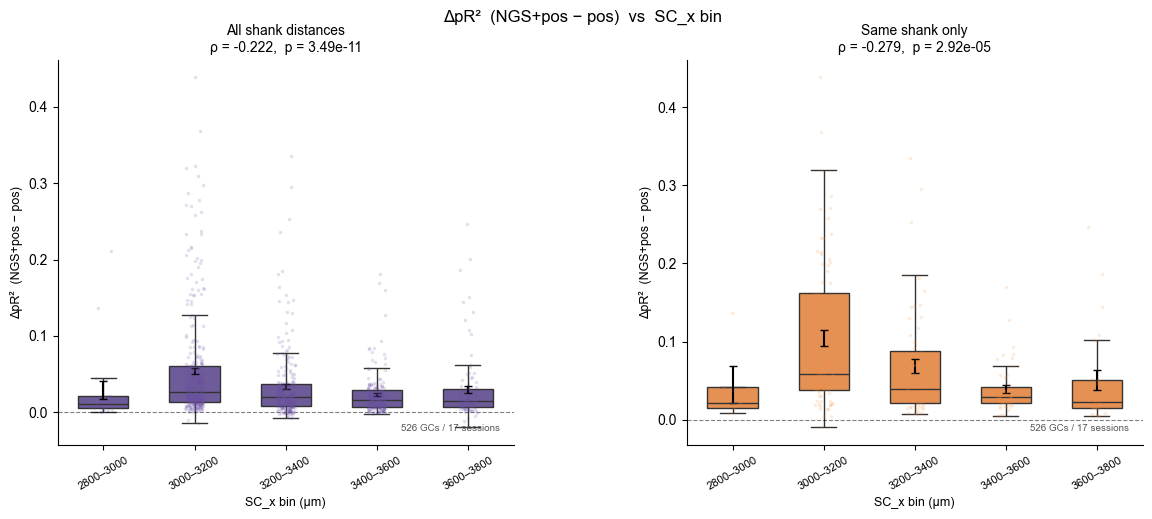

Saved ta_delta_pR2_sc_x_bin.pdf


In [80]:

# ── Delta pR2 (NGS+pos − pos only) vs SC_x bin ───────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

ngs_xgb = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/gc_ngs_shank_xgboost.csv')

# Separate position-only and NGS+pos rows
pos_only = (
    ngs_xgb[ngs_xgb['covariate_type'] == 'pos']
    [['mouse', 'day', 'target_cluster_id', 'target_shank_id', 'pR2_cv']]
    .rename(columns={'pR2_cv': 'pR2_pos', 'target_cluster_id': 'gc_cluster_id',
                     'target_shank_id': 'gc_shank'})
)

pos_ngs = (
    ngs_xgb[ngs_xgb['covariate_type'] == 'pos+ngs_shank']
    [['mouse', 'day', 'target_cluster_id', 'target_shank_id', 'cov_shank_id', 'pR2_cv']]
    .rename(columns={'pR2_cv': 'pR2_pos_ngs', 'target_cluster_id': 'gc_cluster_id',
                     'target_shank_id': 'gc_shank', 'cov_shank_id': 'cov_shank'})
)
pos_ngs['cov_shank'] = pos_ngs['cov_shank'].astype(float).astype('Int64')

# Merge to get delta_pR2 per (mouse, day, gc_cluster_id, cov_shank)
delta_df = pos_ngs.merge(
    pos_only, on=['mouse', 'day', 'gc_cluster_id', 'gc_shank'], how='inner'
)
delta_df['delta_pR2'] = delta_df['pR2_pos_ngs'] - delta_df['pR2_pos']

# Merge with clf_df to get sc_x_bin and shank_dist
sc_x_lookup = (
    clf_df[['mouse', 'day', 'gc_cluster_id', 'gc_shank', 'sc_x', 'sc_x_bin', 'shank_dist', 'cov_shank']]
    .drop_duplicates()
)
sc_x_lookup['cov_shank'] = sc_x_lookup['cov_shank'].astype('Int64')
delta_df = delta_df.merge(
    sc_x_lookup, on=['mouse', 'day', 'gc_cluster_id', 'gc_shank', 'cov_shank'], how='left'
)

sc_x_order_present = [b for b in sc_x_labels if b in delta_df['sc_x_bin'].dropna().unique()]

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={'wspace': 0.38})

# Left: all shank distances
ax = axes[0]
sns.boxplot(
    data=delta_df, x='sc_x_bin', y='delta_pR2',
    order=sc_x_order_present, color='#6a51a3',
    width=0.55, fliersize=0, linecolor='#333333', ax=ax,
)
sns.stripplot(
    data=delta_df, x='sc_x_bin', y='delta_pR2',
    order=sc_x_order_present, color='#6a51a3',
    alpha=0.18, jitter=True, size=2.5, ax=ax,
)
for xi, b in enumerate(sc_x_order_present):
    v = delta_df.loc[delta_df['sc_x_bin'] == b, 'delta_pR2'].dropna()
    if len(v):
        ax.errorbar(xi, v.mean(), yerr=v.sem(),
                    fmt='none', color='k', capsize=3, linewidth=1.5)
r, p = spearmanr(
    delta_df['sc_x'].dropna(),
    delta_df.loc[delta_df['sc_x'].notna(), 'delta_pR2'],
)
p_str = f'{p:.2e}' if p < 0.001 else f'{p:.3f}'
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_title(f'All shank distances\nρ = {r:.3f},  p = {p_str}', fontsize=10)
ax.set_xlabel('SC_x bin (µm)', fontsize=9)
ax.set_ylabel('ΔpR²  (NGS+pos − pos)', fontsize=9)
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: same-shank only (shank_dist == 0)
ax = axes[1]
same_delta = delta_df[delta_df['shank_dist'] == 0]
sc_same_present = [b for b in sc_x_labels if b in same_delta['sc_x_bin'].dropna().unique()]

sns.boxplot(
    data=same_delta, x='sc_x_bin', y='delta_pR2',
    order=sc_same_present, color='#fd8d3c',
    width=0.55, fliersize=0, linecolor='#333333', ax=ax,
)
sns.stripplot(
    data=same_delta, x='sc_x_bin', y='delta_pR2',
    order=sc_same_present, color='#fd8d3c',
    alpha=0.18, jitter=True, size=2.5, ax=ax,
)
for xi, b in enumerate(sc_same_present):
    v = same_delta.loc[same_delta['sc_x_bin'] == b, 'delta_pR2'].dropna()
    if len(v):
        ax.errorbar(xi, v.mean(), yerr=v.sem(),
                    fmt='none', color='k', capsize=3, linewidth=1.5)
if len(same_delta['sc_x'].dropna()) > 1:
    r2, p2 = spearmanr(
        same_delta['sc_x'].dropna(),
        same_delta.loc[same_delta['sc_x'].notna(), 'delta_pR2'],
    )
    p2_str = f'{p2:.2e}' if p2 < 0.001 else f'{p2:.3f}'
    ax.set_title(f'Same shank only\nρ = {r2:.3f},  p = {p2_str}', fontsize=10)
else:
    ax.set_title('Same shank only', fontsize=10)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('SC_x bin (µm)', fontsize=9)
ax.set_ylabel('ΔpR²  (NGS+pos − pos)', fontsize=9)
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

n_gc_v   = delta_df['gc_cluster_id'].nunique()
n_sess_v = delta_df[['mouse', 'day']].drop_duplicates().shape[0]
for ax_ in axes:
    ax_.text(0.97, 0.03, f'{n_gc_v} GCs / {n_sess_v} sessions',
             transform=ax_.transAxes, fontsize=7, ha='right', va='bottom', color='#555555')

fig.suptitle('ΔpR²  (NGS+pos − pos)  vs  SC_x bin', fontsize=12)
os.makedirs(fig_path, exist_ok=True)
plt.savefig(fig_path + 'ta_delta_pR2_sc_x_bin.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved ta_delta_pR2_sc_x_bin.pdf")
